--- Regenerating Simulations... ---
[+] Simulations Regenerated.
--- Liquidity Friction Analysis (Brown) ---
Volatility Scale: 1.0x | Calculated Haircut: 2.50%
--- Liquidity Friction Analysis (Brown) ---
Volatility Scale: 1.5x | Calculated Haircut: 5.00%

--- FINAL THESIS RESULTS: VaR Comparison (Brown Asset) ---
Metric                      | Baseline | Stressed | % Change
----------------------------|----------|----------|---------
Frictionless Value (5th %)  |    56.62 |    28.38 | -49.9%
Liquidity Adjusted Value    |    55.21 |    26.96 | -51.2%
----------------------------|----------|----------|---------
Liquidity 'Haircut' Cost    |    2.50% |    5.00% |


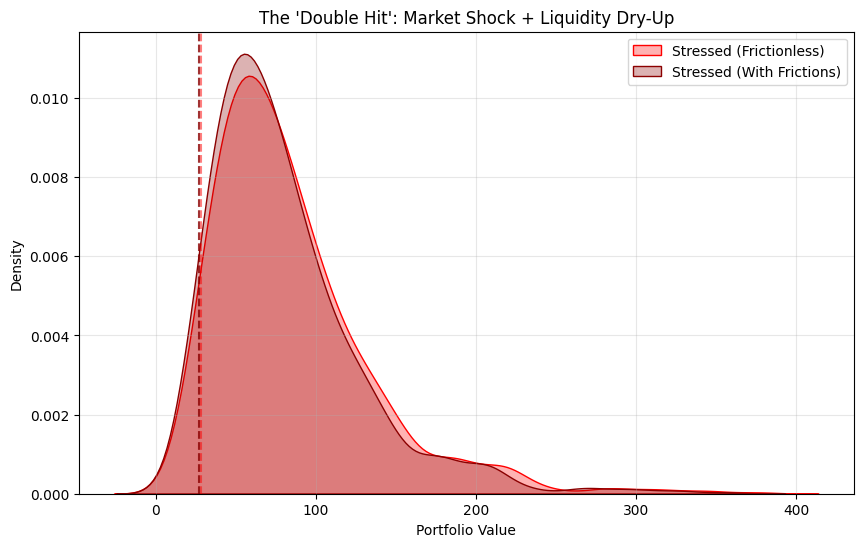

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Path & Data Setup ---
current_dir = os.getcwd()
if current_dir.endswith("notebooks"):
    PROJECT_ROOT = os.path.dirname(current_dir)
else:
    PROJECT_ROOT = current_dir

# Load Data
data_path = os.path.join(PROJECT_ROOT, "data", "processed", "market_returns.csv")
returns_df = pd.read_csv(data_path, index_col=0)

# --- 2. Re-Define Engines (Ensuring classes exist) ---
# (Brief re-definition to ensure this cell runs standalone if needed)
class MonteCarloEngine:
    def __init__(self, returns_data):
        self.returns = returns_data
        self.assets = returns_data.columns
        self.n_assets = len(self.assets)
        self.mu = self.returns.mean() * 252
        self.cov_matrix = self.returns.cov() * 252
        self.L = np.linalg.cholesky(self.cov_matrix)
        
    def simulate(self, T_years=1, n_scenarios=1000, dt=1/252):
        n_steps = int(T_years / dt)
        paths = np.zeros((n_scenarios, n_steps + 1, self.n_assets))
        paths[:, 0, :] = 100 
        for t in range(1, n_steps + 1):
            Z_uncorr = np.random.normal(0, 1, size=(n_scenarios, self.n_assets))
            Z_corr = Z_uncorr @ self.L.T
            drift = (self.mu.values - 0.5 * np.diag(self.cov_matrix)) * dt
            diffusion = Z_corr * np.sqrt(dt)
            paths[:, t, :] = paths[:, t-1, :] * np.exp(drift + diffusion)
        return paths

class StressScenarioEngine(MonteCarloEngine):
    def simulate_stressed(self, shocks, T_years=1, n_scenarios=1000, dt=1/252):
        n_steps = int(T_years / dt)
        paths = np.zeros((n_scenarios, n_steps + 1, self.n_assets))
        paths[:, 0, :] = 100
        
        stressed_mu = self.mu.copy()
        for asset, shock_val in shocks['drift'].items():
            if asset in stressed_mu.index:
                stressed_mu[asset] += shock_val
        
        vol_mult = shocks.get('vol_multiplier', 1.0)
        stressed_cov = self.cov_matrix * (vol_mult ** 2)
        L_stressed = np.linalg.cholesky(stressed_cov)
        
        for t in range(1, n_steps + 1):
            Z_uncorr = np.random.normal(0, 1, size=(n_scenarios, self.n_assets))
            Z_corr = Z_uncorr @ L_stressed.T
            drift = (stressed_mu.values - 0.5 * np.diag(stressed_cov)) * dt
            diffusion = Z_corr * np.sqrt(dt)
            paths[:, t, :] = paths[:, t-1, :] * np.exp(drift + diffusion)
        return paths

# --- 3. Run Simulations (Regenerate Missing Data) ---
print("--- Regenerating Simulations... ---")
mc_engine = MonteCarloEngine(returns_df)
sim_paths = mc_engine.simulate(T_years=1, n_scenarios=1000)

stress_config = {
    'drift': {'Brown': -0.30, 'Green': +0.10, 'Market': -0.05, 'Oil': -0.20},
    'vol_multiplier': 1.5
}
stress_engine = StressScenarioEngine(returns_df)
stressed_paths = stress_engine.simulate_stressed(stress_config, T_years=1, n_scenarios=1000)
print("[+] Simulations Regenerated.")

# --- 4. Liquidity Friction Logic ---
def calculate_liquidity_adjusted_var(terminal_prices, vol_scaling_factor, asset_type='Brown'):
    # Parameters for 'Brown' assets (High Liquidity Risk)
    if asset_type == 'Brown':
        base_spread = 0.0050  # 50 bps normal spread
        sensitivity = 0.0200  # 2% impact per unit of vol squared
    else:
        base_spread = 0.0010 
        sensitivity = 0.0050
        
    # Liquidity Penalty = Base + Sensitivity * (Vol_Scale^2)
    liquidity_penalty = base_spread + sensitivity * (vol_scaling_factor ** 2)
    
    print(f"--- Liquidity Friction Analysis ({asset_type}) ---")
    print(f"Volatility Scale: {vol_scaling_factor}x | Calculated Haircut: {liquidity_penalty:.2%}")
    
    adjusted_prices = terminal_prices * (1 - liquidity_penalty)
    return adjusted_prices, liquidity_penalty

# --- 5. Analysis & Visualization ---
# Asset Index 3 = Brown (XLE)
asset_idx = 3 
base_prices = sim_paths[:, -1, asset_idx]
stress_prices = stressed_paths[:, -1, asset_idx]

# A. Calculate Frictionless VaR (95%)
var_95_base_raw = np.percentile(base_prices, 5)
var_95_stress_raw = np.percentile(stress_prices, 5)

# B. Calculate Liquidity-Adjusted VaR
base_prices_adj, cost_base = calculate_liquidity_adjusted_var(base_prices, 1.0, 'Brown')
stress_prices_adj, cost_stress = calculate_liquidity_adjusted_var(stress_prices, 1.5, 'Brown')

var_95_base_adj = np.percentile(base_prices_adj, 5)
var_95_stress_adj = np.percentile(stress_prices_adj, 5)

# Report
print(f"\n--- FINAL THESIS RESULTS: VaR Comparison (Brown Asset) ---")
print(f"Metric                      | Baseline | Stressed | % Change")
print(f"----------------------------|----------|----------|---------")
print(f"Frictionless Value (5th %)  | {var_95_base_raw:8.2f} | {var_95_stress_raw:8.2f} | {(var_95_stress_raw/var_95_base_raw - 1):.1%}")
print(f"Liquidity Adjusted Value    | {var_95_base_adj:8.2f} | {var_95_stress_adj:8.2f} | {(var_95_stress_adj/var_95_base_adj - 1):.1%}")
print(f"----------------------------|----------|----------|---------")
print(f"Liquidity 'Haircut' Cost    | {cost_base:8.2%} | {cost_stress:8.2%} |")

# Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(stress_prices, fill=True, color='red', alpha=0.3, label='Stressed (Frictionless)')
sns.kdeplot(stress_prices_adj, fill=True, color='darkred', alpha=0.3, label='Stressed (With Frictions)')
plt.axvline(var_95_stress_raw, color='red', linestyle='--', alpha=0.5)
plt.axvline(var_95_stress_adj, color='darkred', linestyle='--', alpha=0.8)
plt.title("The 'Double Hit': Market Shock + Liquidity Dry-Up")
plt.xlabel("Portfolio Value")
plt.legend()
plt.grid(True, alpha=0.3)

save_path = os.path.join(PROJECT_ROOT, "outputs", "figures", "liquidity_impact.png")
plt.savefig(save_path)
plt.show()